# 08 — Model Comparison (ENACT)

Compare any number of evaluated models side-by-side on the WHO ENACT rubric
(items 2–15, levels 1–4 — see notebook 07 for the adaptation).

Just add model names to the `MODELS` list below — each must have a corresponding
`reports/enact/<model_name>/enact_eval_scores.csv` produced by `src/scripts/enact_eval.py`.
All charts are saved under `reports/enact/`, separate from the CTRS-R outputs of notebook 06.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src.scripts.enact_eval import ITEM_KEYS, ITEM_LABELS

## Configuration

Add or remove model names. Each must have been scored with `src/scripts/enact_eval.py`.

In [2]:
# ── Models to compare ─────────────────────────────────────────────────────────
# Each entry is a folder name under reports/enact/
MODELS = [
    "base",
    "Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged",
    "Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged",
    "Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged",
    "Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged",
]

ENACT_DIR = Path("../reports/enact")

N_ITEMS = len(ITEM_KEYS)          # 14 (items 2-15; item 1 is non-verbal, excluded)
TOTAL_MIN, TOTAL_MAX = N_ITEMS, N_ITEMS * 4   # 14-56

# Verify all reports exist
for name in MODELS:
    csv_path = ENACT_DIR / name / "enact_eval_scores.csv"
    assert csv_path.exists(), f"Missing: {csv_path} — run src/scripts/enact_eval.py first"
    print(f"  ✓ {name}: {csv_path}")
print(f"\nComparing {len(MODELS)} models.")

# ── Short display names for charts ────────────────────────────────────────────
SHORT_NAMES = {
    "base": "Base",
    "Qwen3.5-4B-SFT-CACTUS-iter_02": "SFT only (iter 2)",
    "Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged": "SFT+KTO (iter 1)",
    "Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged": "SFT+KTO (iter 2)",
    "Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged": "SFT+DPO (iter 1)",
    "Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged": "SFT+DPO (iter 2)",
}

def short(name):
    """Chart display name for a model folder (falls back to the folder name)."""
    return SHORT_NAMES.get(name, name)

  ✓ base: ../reports/enact/base/enact_eval_scores.csv
  ✓ Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged: ../reports/enact/Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged/enact_eval_scores.csv
  ✓ Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged: ../reports/enact/Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged/enact_eval_scores.csv
  ✓ Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged: ../reports/enact/Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged/enact_eval_scores.csv
  ✓ Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged: ../reports/enact/Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged/enact_eval_scores.csv

Comparing 5 models.


## Load Scores

In [3]:
# Load all score CSVs
dfs = {}
for name in MODELS:
    df = pd.read_csv(ENACT_DIR / name / "enact_eval_scores.csv")
    dfs[name] = df
    print(f"{name}: {len(df)} scored transcripts, mean level={df[ITEM_KEYS].mean().mean():.2f}")

# Per-item means and 95% CI half-widths (1.96 × SEM) for each model
means = {name: df[ITEM_KEYS].mean() for name, df in dfs.items()}
cis = {name: 1.96 * df[ITEM_KEYS].sem() for name, df in dfs.items()}
means_df = pd.DataFrame(means).T
means_df.columns = [l.replace("\n", " ") for l in ITEM_LABELS]
print("\nPer-item mean levels:")
means_df

base: 100 scored transcripts, mean level=3.40
Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged: 100 scored transcripts, mean level=3.49
Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged: 100 scored transcripts, mean level=3.48
Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged: 100 scored transcripts, mean level=3.44
Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged: 100 scored transcripts, mean level=3.45

Per-item mean levels:


,Verbal Comm.,Confident- iality,Rapport,Feelings Explor.,Empathy,Harm Assess.,Social Funct.,Explan. Models,Family Involv.,Goal Setting,Hope,Coping,Psycho- education,Feedback Elicit.
base,3.960000,2.0,2.990000,3.980000,3.320000,2.000000,3.690000,3.550000,2.440000,3.880000,3.930000,3.960000,3.850000,3.980000
Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged,3.969697,2.0,3.202020,3.989899,3.606061,2.000000,3.787879,3.757576,2.626263,4.000000,3.979798,3.989899,3.919192,3.989899
Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged,3.949495,2.0,3.202020,3.969697,3.585859,2.020202,3.747475,3.656566,2.707071,3.989899,3.979798,4.000000,3.878788,3.989899
Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged,3.919192,2.0,3.080808,3.959596,3.454545,2.000000,3.707071,3.727273,2.606061,3.939394,3.959596,3.969697,3.878788,3.979798
Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged,3.887755,2.0,3.132653,3.948980,3.500000,2.000000,3.724490,3.673469,2.642857,3.969388,3.948980,4.000000,3.897959,4.000000


## Comparison Bar Chart

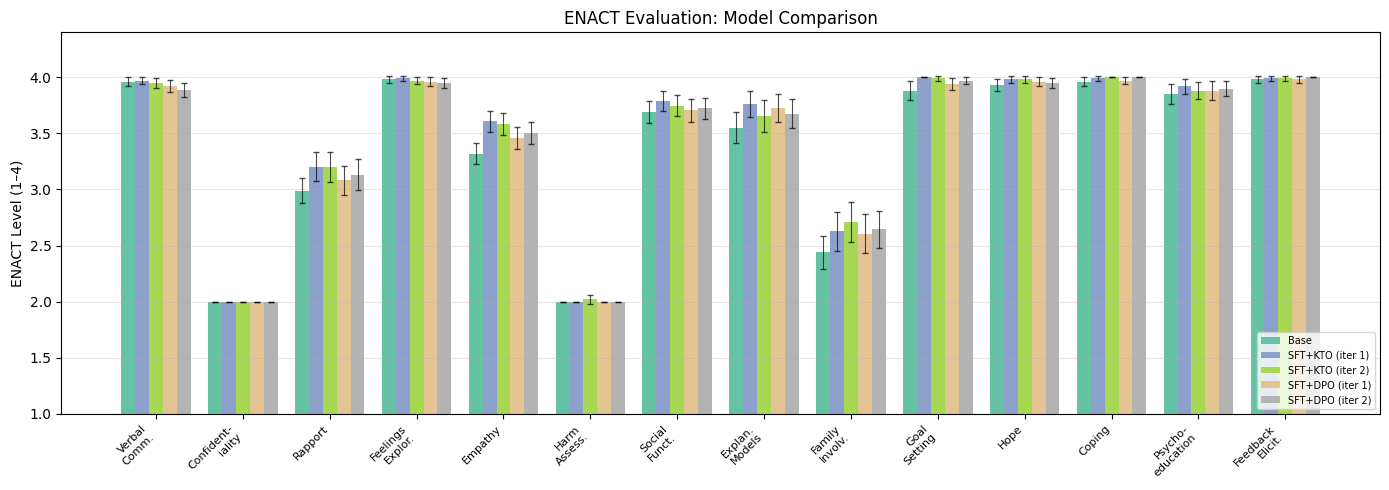

Chart saved → ../reports/enact/enact_comparison_chart.png


In [7]:
n_models = len(MODELS)
x = np.arange(N_ITEMS)
width = 0.8 / n_models  # bar width scales with number of models

# Color palette
colors = plt.cm.Set2(np.linspace(0, 1, max(n_models, 3)))

fig, ax = plt.subplots(figsize=(14, 5))

for i, name in enumerate(MODELS):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, means[name].values, width, label=short(name), color=colors[i],
           yerr=cis[name].values, capsize=2, error_kw={"lw": 0.8, "alpha": 0.7})

ax.set_ylabel("ENACT Level (1–4)")
ax.set_title("ENACT Evaluation: Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(ITEM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylim(1, 4.4)
ax.legend(loc="lower right", fontsize=7)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

chart_path = ENACT_DIR / "enact_comparison_chart.png"
fig.savefig(chart_path, dpi=150)
plt.show()
print(f"Chart saved → {chart_path}")

## Overall Total Score Comparison

ENACT total = sum of the 14 items (14–56), averaged across transcripts. Transcripts with any missing item are excluded.

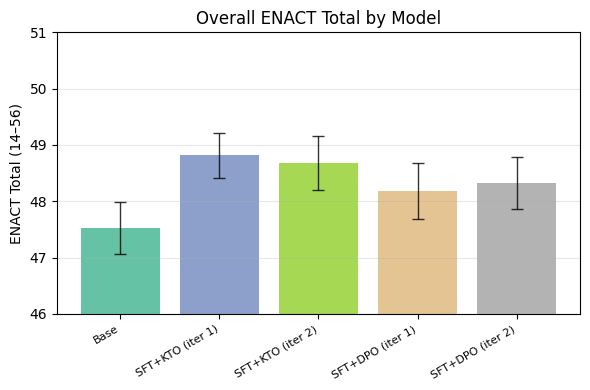

Chart saved → ../reports/enact/enact_total_chart.png

Total scores (mean ± 95% CI):
  base: 47.53 ± 0.46 / 56
  Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged: 48.82 ± 0.40 / 56
  Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged: 48.68 ± 0.48 / 56
  Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged: 48.18 ± 0.50 / 56
  Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged: 48.33 ± 0.46 / 56


In [5]:
# Mean ENACT total (sum of 14 items, 14-56) per model.
# min_count drops transcripts with any missing item instead of treating NaN as 0.
total_series = {
    name: df[ITEM_KEYS].sum(axis=1, min_count=N_ITEMS)
    for name, df in dfs.items()
}
totals = {name: s.mean() for name, s in total_series.items()}
total_cis = {name: 1.96 * s.sem() for name, s in total_series.items()}  # 95% CI

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([short(n) for n in totals], totals.values(), color=colors[:n_models],
       yerr=list(total_cis.values()), capsize=4, error_kw={"lw": 1, "alpha": 0.8})
ax.set_ylabel("ENACT Total (14–56)")
ax.set_title("Overall ENACT Total by Model")

# Zoom in on the occupied range (note: y-axis does not start at 14)
lo = min(t - c for t, c in zip(totals.values(), total_cis.values()))
hi = max(t + c for t, c in zip(totals.values(), total_cis.values()))
ax.set_ylim(np.floor(lo) - 1, np.ceil(hi) + 1)

ax.grid(axis="y", alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

fig.tight_layout()
total_path = ENACT_DIR / "enact_total_chart.png"
fig.savefig(total_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {total_path}")

print("\nTotal scores (mean ± 95% CI):")
for name in totals:
    print(f"  {name}: {totals[name]:.2f} ± {total_cis[name]:.2f} / {TOTAL_MAX}")

## Head-to-Head Comparison (Win/Tie/Loss)

Compare two models per-vignette: for each ENACT item, count how often each model scored higher (win), tied, or scored lower. Displayed as horizontal stacked bars summing to 100%.

Shared vignettes: 100


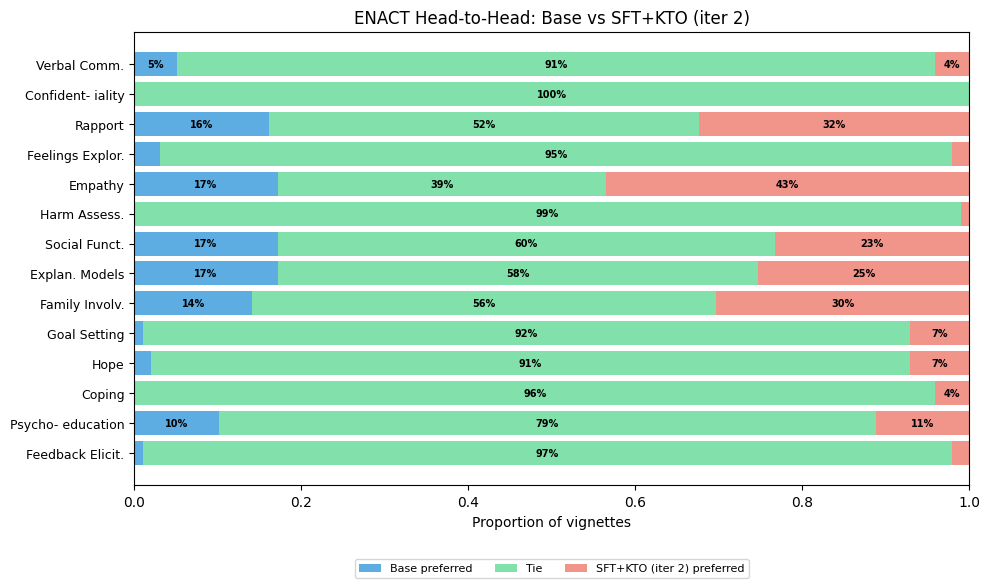

Chart saved → ../reports/enact/h2h_base_vs_Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged.png


In [6]:
# ── Head-to-head config ───────────────────────────────────────────────────────
# Pick two models to compare. "baseline" is shown on the left, "challenger" on the right.
BASELINE    = "base"
CHALLENGER  = "Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged"

assert BASELINE in dfs, f"'{BASELINE}' not loaded — add it to MODELS above"
assert CHALLENGER in dfs, f"'{CHALLENGER}' not loaded — add it to MODELS above"

# Align on shared vignettes
df_b = dfs[BASELINE].set_index("vignette")
df_c = dfs[CHALLENGER].set_index("vignette")
shared = df_b.index.intersection(df_c.index)
print(f"Shared vignettes: {len(shared)}")

# Per-item win/tie/loss counts
wins_b, ties, wins_c = [], [], []
for key in ITEM_KEYS:
    sb = df_b.loc[shared, key].values
    sc = df_c.loc[shared, key].values
    # Drop pairs where either is NaN
    mask = ~(np.isnan(sb) | np.isnan(sc))
    sb, sc = sb[mask], sc[mask]
    n = len(sb)
    w_b = int((sb > sc).sum())
    w_c = int((sc > sb).sum())
    t = n - w_b - w_c
    wins_b.append(w_b / n)
    ties.append(t / n)
    wins_c.append(w_c / n)

wins_b = np.array(wins_b)
ties = np.array(ties)
wins_c = np.array(wins_c)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(ITEM_KEYS))

ax.barh(y, wins_b, color="#5dade2", label=f"{short(BASELINE)} preferred")
ax.barh(y, ties, left=wins_b, color="#82e0aa", label="Tie")
ax.barh(y, wins_c, left=wins_b + ties, color="#f1948a", label=f"{short(CHALLENGER)} preferred")

ax.set_yticks(y)
ax.set_yticklabels([l.replace("\n", " ") for l in ITEM_LABELS], fontsize=9)
ax.set_xlabel("Proportion of vignettes")
ax.set_xlim(0, 1)
ax.set_title(f"ENACT Head-to-Head: {short(BASELINE)} vs {short(CHALLENGER)}")
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=3, fontsize=8)
ax.invert_yaxis()

# Add percentage labels
for i in range(len(ITEM_KEYS)):
    if wins_b[i] > 0.04:
        ax.text(wins_b[i] / 2, i, f"{wins_b[i]:.0%}", ha="center", va="center", fontsize=7, fontweight="bold")
    if ties[i] > 0.04:
        ax.text(wins_b[i] + ties[i] / 2, i, f"{ties[i]:.0%}", ha="center", va="center", fontsize=7, fontweight="bold")
    if wins_c[i] > 0.04:
        ax.text(wins_b[i] + ties[i] + wins_c[i] / 2, i, f"{wins_c[i]:.0%}", ha="center", va="center", fontsize=7, fontweight="bold")

fig.tight_layout()

h2h_path = ENACT_DIR / f"h2h_{BASELINE}_vs_{CHALLENGER}.png"
fig.savefig(h2h_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {h2h_path}")

## Training Progression: KTO vs DPO Loop

Mean ENACT total (14–56) across loop iterations, starting with the shared
base model. Shaded bands are 95% CIs across the test vignettes.

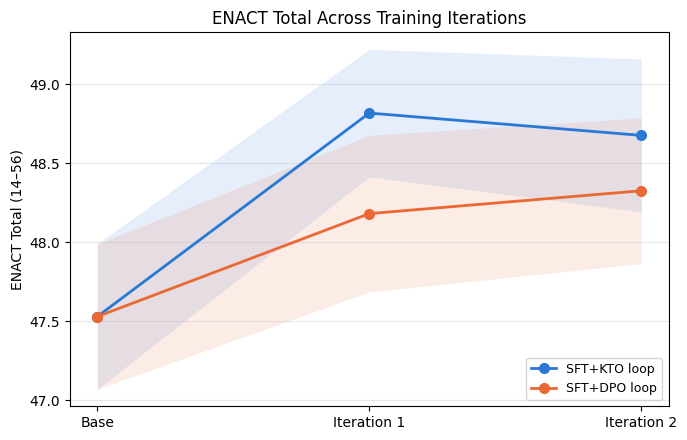

Chart saved → ../reports/enact/enact_progression_kto_vs_dpo.png

Progression (mean ± 95% CI):
  SFT+KTO loop: 47.53 ± 0.46  →  48.82 ± 0.40  →  48.68 ± 0.48
  SFT+DPO loop: 47.53 ± 0.46  →  48.18 ± 0.50  →  48.33 ± 0.46


In [8]:
# ── Loop progressions ─────────────────────────────────────────────────────────
# Both loops start from the same base model (iteration 0).
PROGRESSIONS = {
    "SFT+KTO loop": [
        "base",
        "Qwen3.5-4B-SFT-KTO-CACTUS-iter_01-merged",
        "Qwen3.5-4B-SFT-KTO-CACTUS-iter_02-merged",
    ],
    "SFT+DPO loop": [
        "base",
        "Qwen3.5-4B-SFT-DPO-CACTUS-iter_01-merged",
        "Qwen3.5-4B-SFT-DPO-CACTUS-iter_02-merged",
    ],
}
LINE_COLORS = {"SFT+KTO loop": "#2a78d6", "SFT+DPO loop": "#eb6834"}

for loop_name, prog in PROGRESSIONS.items():
    missing = [m for m in prog if m not in dfs]
    assert not missing, f"{loop_name}: not loaded — add to MODELS above: {missing}"

# Per-transcript ENACT totals; min_count drops transcripts with any missing item
prog_totals = {
    m: dfs[m][ITEM_KEYS].sum(axis=1, min_count=N_ITEMS)
    for prog in PROGRESSIONS.values() for m in prog
}

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(max(len(p) for p in PROGRESSIONS.values()))

for loop_name, prog in PROGRESSIONS.items():
    y = np.array([prog_totals[m].mean() for m in prog])
    ci = np.array([1.96 * prog_totals[m].sem() for m in prog])
    color = LINE_COLORS[loop_name]
    ax.plot(x[: len(prog)], y, marker="o", markersize=7, linewidth=2,
            color=color, label=loop_name)
    ax.fill_between(x[: len(prog)], y - ci, y + ci, color=color, alpha=0.12, lw=0)

ax.set_xticks(x)
ax.set_xticklabels(["Base", "Iteration 1", "Iteration 2"])
ax.set_ylabel("ENACT Total (14–56)")
ax.set_title("ENACT Total Across Training Iterations")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

prog_path = ENACT_DIR / "enact_progression_kto_vs_dpo.png"
fig.savefig(prog_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {prog_path}")

print("\nProgression (mean ± 95% CI):")
for loop_name, prog in PROGRESSIONS.items():
    pts = [f"{prog_totals[m].mean():.2f} ± {1.96 * prog_totals[m].sem():.2f}" for m in prog]
    print(f"  {loop_name}: " + "  →  ".join(pts))